In [ ]:
#The data set is UCI library and using direct code from UCI library to laod the data
#This block will load all required packages in one go and required packages will be installed
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df = pd.read_csv('/bank-full.csv',sep = ';')
df = df.rename(columns={'y':'target'})
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
for i in df.select_dtypes(include='object').columns:
    print(f"{i}:")
    print(df[i].unique())
    print("\n")

job:
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']


marital:
['married' 'single' 'divorced']


education:
['tertiary' 'secondary' 'unknown' 'primary']


default:
['no' 'yes']


housing:
['yes' 'no']


loan:
['no' 'yes']


contact:
['unknown' 'cellular' 'telephone']


month:
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']


poutcome:
['unknown' 'failure' 'other' 'success']


target:
['no' 'yes']




In [ ]:
#Get data frame column type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
#Get null count of the data set
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
# Calculate the percentage of null values for each column
null_percentages = (df.isnull().sum() / len(df)) * 100

# Display the null percentages, sorted in descending order
display(null_percentages.sort_values(ascending=False))

,0
poutcome,81.747805
contact,28.798301
education,4.107407
job,0.637013
age,0.000000
default,0.000000
balance,0.000000
housing,0.000000
marital,0.000000
loan,0.000000


In [ ]:
df[df['poutcome'].isna()==False]
# The abovce poutcome variable is useful to check what happened in the previous outcome but 82% null values will definitely not help here so will be removing

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [10]:
df[df['contact'].isna()==False]
#Contact here does not make sense how it was called. on cellular or on telephone. Also, it is 30% missing values

NameError: name 'df' is not defined

In [ ]:
df = df.drop(columns=['poutcome','contact'], axis=1)
df.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,target
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0,no
3,47,blue-collar,married,unknown,no,1506,yes,no,5,may,92,1,-1,0,no
4,33,unknown,single,unknown,no,1,no,no,5,may,198,1,-1,0,no


In [ ]:
df.shape

(45211, 15)

In [ ]:
#now focus on null for Job and education, rather than filling up the valuye it is better to remove null
df = df.dropna().reset_index()
df = df.drop(columns=['index'], axis=1)
df.shape


(45211, 15)

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,target
0,58,management,married,tertiary,no,2143,yes,no,5,may,261,1,-1,0,no
1,44,technician,single,secondary,no,29,yes,no,5,may,151,1,-1,0,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,76,1,-1,0,no
3,47,blue-collar,married,unknown,no,1506,yes,no,5,may,92,1,-1,0,no
4,33,unknown,single,unknown,no,1,no,no,5,may,198,1,-1,0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,17,nov,977,3,-1,0,yes
45207,71,retired,divorced,primary,no,1729,no,no,17,nov,456,2,-1,0,yes
45208,72,retired,married,secondary,no,5715,no,no,17,nov,1127,5,184,3,yes
45209,57,blue-collar,married,secondary,no,668,no,no,17,nov,508,4,-1,0,no


. Define the Architecture: Create a Keras Sequential model with the following layers:
• An appropriate input layer
• A Dense layer with 32 neurons, tanh activation, and the correct input_shape.
• A Dropout layer that randomly drops 20% of the neurons.
• A Dense output layer with the appropriate number of neurons and activation function
for this binary classification proble

### Training the Model

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8191 - loss: 0.3875 - val_accuracy: 0.8944 - val_loss: 0.2475
Epoch 2/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8946 - loss: 0.2508 - val_accuracy: 0.8948 - val_loss: 0.2419
Epoch 3/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8940 - loss: 0.2484 - val_accuracy: 0.8948 - val_loss: 0.2386
Epoch 4/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8910 - loss: 0.2486 - val_accuracy: 0.8962 - val_loss: 0.2363
Epoch 5/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8969 - loss: 0.2426 - val_accuracy: 0.8967 - val_loss: 0.2337
Epoch 6/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8935 - loss: 0.2442 - val_accuracy: 0.8959 - val_loss: 0.2329
Epoch 7/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8930 - loss: 0.2379 - val_accuracy: 0.8974 - val_loss: 0.2315
Epoch 8/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8955 - loss: 0.2376 - val_accuracy: 0.

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8969 - loss: 0.2341 - val_accuracy: 0.8988 - val_loss: 0.2270
Epoch 2/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8961 - loss: 0.2374 - val_accuracy: 0.9002 - val_loss: 0.2252
Epoch 3/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8967 - loss: 0.2325 - val_accuracy: 0.9009 - val_loss: 0.2234
Epoch 4/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8960 - loss: 0.2373 - val_accuracy: 0.9016 - val_loss: 0.2227
Epoch 5/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9015 - loss: 0.2243 - val_accuracy: 0.9021 - val_loss: 0.2215
Epoch 6/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8970 - loss: 0.2289 - val_accuracy: 0.9021 - val_loss: 0.2216
Epoch 7/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8975 - loss: 0.2279 - val_accuracy: 0.9024 - val_loss: 0.2212
Epoch 8/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9020 - loss: 0.2255 - val_accuracy: 0.

### Training the Model

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8943 - loss: 0.2309 - val_accuracy: 0.9023 - val_loss: 0.2194
Epoch 2/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9014 - loss: 0.2225 - val_accuracy: 0.9032 - val_loss: 0.2186
Epoch 3/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8979 - loss: 0.2283 - val_accuracy: 0.9027 - val_loss: 0.2193
Epoch 4/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9018 - loss: 0.2186 - val_accuracy: 0.9038 - val_loss: 0.2182
Epoch 5/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9003 - loss: 0.2232 - val_accuracy: 0.9036 - val_loss: 0.2175
Epoch 6/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9036 - loss: 0.2188 - val_accuracy: 0.9036 - val_loss: 0.2168
Epoch 7/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9029 - loss: 0.2221 - val_accuracy: 0.9034 - val_loss: 0.2165
Epoch 8/10
905/905 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9000 - loss: 0.2291 - val_accuracy: 0.

### Training the Model

In [9]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

NameError: name 'model' is not defined

### Preprocessing the Data for Keras Model

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

# Convert target to numerical (0 and 1)
y = y.apply(lambda x: 1 if x == 'yes' else 0)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (45211, 14)
Shape of y: (45211,)


In [ ]:
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical columns: {list(categorical_cols)}")
print(f"Numerical columns: {list(numerical_cols)}")

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month']
Numerical columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

print(f"Shape of preprocessed X: {X_processed.shape}")

Shape of preprocessed X: (45211, 44)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (36168, 44)
Shape of X_test: (9043, 44)
Shape of y_train: (36168,)
Shape of y_test: (9043,)


### Defining the Keras Sequential Model Architecture

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Determine the input shape from the preprocessed data
input_shape = X_train.shape[1]

# Create the Keras Sequential model
model = keras.Sequential([
    layers.Input(shape=(input_shape,)), # Appropriate input layer
    layers.Dense(32, activation='tanh', input_shape=(input_shape,)), # Dense layer with 32 neurons, tanh activation
    layers.Dropout(0.2), # Dropout layer that randomly drops 20% of the neurons
    layers.Dense(1, activation='sigmoid') # Dense output layer for binary classification
])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

 B.Compile the Model: Compile the model using the following:
• Optimizer: Stochastic Gradient Descent (SGD) with a learning rate of 0.01, momentum
of 0.9, and Nesterov momentum enabled.
• Loss Function: binary_crossentropy, as this is a binary classification task.
• Metrics: Track accuracy

### Evaluating the Model

In [ ]:
import tensorflow as tf

sgd_optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
model.compile(optimizer=sgd_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5398 - loss: 0.7170
Test Loss: 0.7102
Test Accuracy: 0.5556


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5398 - loss: 0.7170
Test Loss: 0.7102
Test Accuracy: 0.5556


### Evaluating the Model

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5398 - loss: 0.7170
Test Loss: 0.7102
Test Accuracy: 0.5556


c. Train the Model: Train the model on the training dataset for 20 epochs with a batch size of 64.
Use 20% of your training data as a validation set (validation_split=0.2)

In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2)

Epoch 1/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8688 - loss: 0.3218 - val_accuracy: 0.8922 - val_loss: 0.2519
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8893 - loss: 0.2592 - val_accuracy: 0.8940 - val_loss: 0.2447
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8895 - loss: 0.2555 - val_accuracy: 0.8938 - val_loss: 0.2408
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8918 - loss: 0.2512 - val_accuracy: 0.8945 - val_loss: 0.2391
Epoch 5/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8909 - loss: 0.2516 - val_accuracy: 0.8965 - val_loss: 0.2373
Epoch 6/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8891 - loss: 0.2510 - val_accuracy: 0.8922 - val_loss: 0.2389
Epoch 7/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8887 - loss: 0.2530 - val_accuracy: 0.8944 - val_loss: 0.2367
Epoch 8/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8880 - loss: 0.2523 - val_accuracy: 0.

D.Evaluate Performance:
• Plot the training and validation accuracy over epochs.
• Plot the training and validation loss over epochs.
• Evaluate the final model on the unseen test data (X_test, y_test) and report the test
accuracy and test loss.
• Generate and display a confusion matrix for the model's predictions on the test dat

### Evaluating the Model Performance

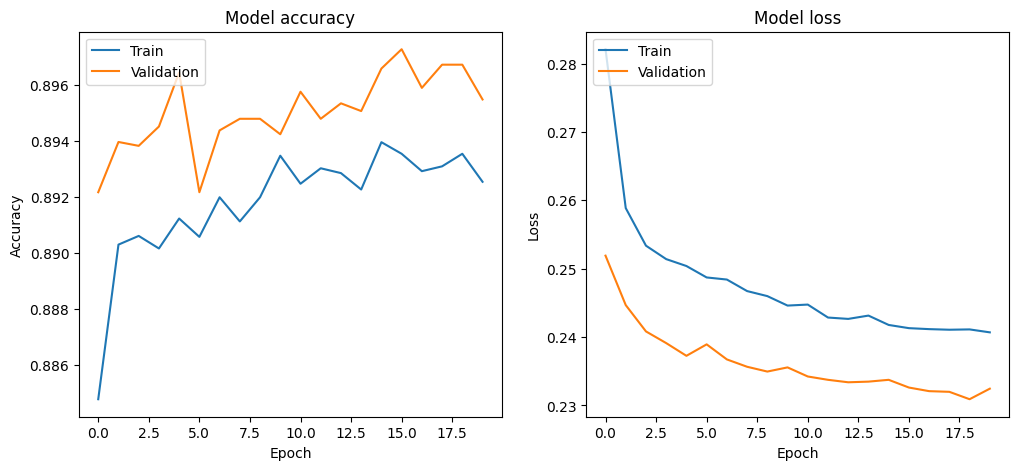

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
# Evaluate the final model on the unseen test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8973 - loss: 0.2366

Test Loss: 0.2371
Test Accuracy: 0.8943


283/283 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


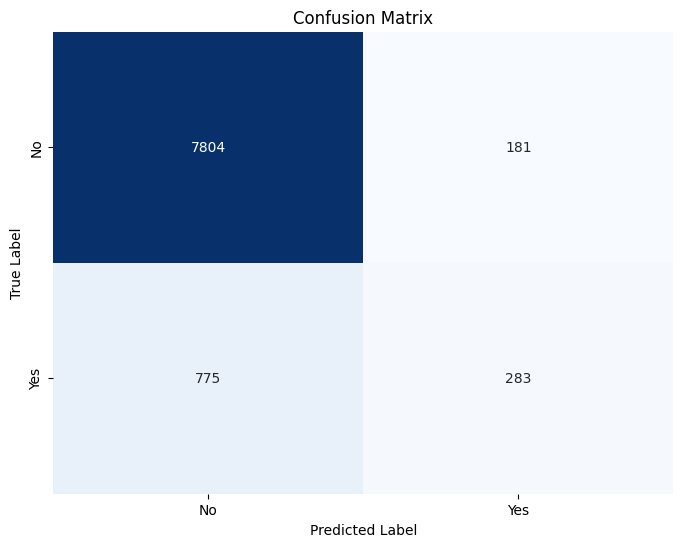

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict probabilities for the test set
y_pred_proba = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_proba > 0.5).astype(int)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Part 3: Hyperparameter Tuning with Keras Tune

a. Build the Hypermodel: Create a model-building function for Keras Tuner. The model inside
this function should have:
• A first Dense hidden layer with a tunable number of units. Use the
hyperparameter hp.Int('units_1', min_value=16, max_value=256, step=32). Use
the relu activation function.
• A second Dense hidden layer with a tunable number of units. Use hp.Int('units_2',
min_value=12, max_value=120, step=12). Use the relu activation function.
• An appropriate Dense output layer.
• Compile the model within the function. Use the Adam optimizer and tune the learning
rate. Test the values [0.01, 0.001, 0.0001]

# Task
Define a Keras Hypermodel function named `build_model` that takes `hp` as input. The model should include a first `Dense` layer with tunable units from 16 to 256 (step 32, ReLU activation), a second `Dense` layer with tunable units from 12 to 120 (step 12, ReLU activation), and a single-unit `Dense` output layer (sigmoid activation). Compile the model with the Adam optimizer, a tunable learning rate (0.01, 0.001, 0.0001), and 'binary_crossentropy' loss.

## Build Hypermodel Function

### Subtask:
Define the `build_model` function for Keras Tuner. This function will accept a hyperparameter object `hp` and construct a Keras Sequential model. It will include a first Dense layer with tunable units (16-256, step 32, ReLU activation), a second Dense layer with tunable units (12-120, step 12, ReLU activation), and a single-unit Dense output layer with sigmoid activation for binary classification. The model will be compiled using the Adam optimizer with a tunable learning rate (0.01, 0.001, 0.0001) and 'binary_crossentropy' loss.


**Reasoning**:
I need to define the `build_model` function for Keras Tuner as specified in the subtask. This function will build a Keras Sequential model with tunable Dense layers and a tunable learning rate for the Adam optimizer.



In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_shape,)))
    model.add(layers.Dense(units=hp.Int('units_1', min_value=16, max_value=256, step=32), activation='relu'))
    model.add(layers.Dense(units=hp.Int('units_2', min_value=12, max_value=120, step=12), activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

print("build_model function defined for Keras Tuner.")

build_model function defined for Keras Tuner.


## Final Task

### Subtask:
Confirm that the hypermodel function has been successfully defined and is ready for use with Keras Tuner.


## Summary:

### Q&A
The hypermodel function `build_model` has been successfully defined and is ready for use with Keras Tuner.

### Data Analysis Key Findings
*   A Keras Sequential model was defined within the `build_model` function, taking a hyperparameter object (`hp`) as input.
*   The model includes an initial `Input` layer, followed by two `Dense` hidden layers.
*   The first `Dense` layer's units are tunable between 16 and 256, with a step of 32, using ReLU activation.
*   The second `Dense` layer's units are tunable between 12 and 120, with a step of 12, also using ReLU activation.
*   The output layer is a single-unit `Dense` layer with sigmoid activation, suitable for binary classification.
*   The model is compiled with the Adam optimizer, and its learning rate is tunable among three values: 0.01, 0.001, and 0.0001.
*   The loss function is set to 'binary_crossentropy', and 'accuracy' is used as a metric.

### Insights or Next Steps
*   The defined `build_model` function is now prepared to be passed to a Keras Tuner instance (e.g., `RandomSearch` or `Hyperband`) to search for the optimal hyperparameters.
*   The next logical step would be to instantiate a Keras Tuner, feed it this `build_model` function, and then run the hyperparameter search using appropriate training data.


b,Instantiate the Tuner:
• Instantiate the Hyperband tuner to perform the search.
• The objective should be to maximize val_accuracy.

### Instantiate Hyperband Tuner

### Run Hyperparameter Search

In [8]:
!pip install keras-tuner
import keras_tuner as kt

tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=20,
                     factor=3,
                     directory='my_dir',
                     project_name='intro_to_kt')

tuner.search(X_train, y_train, epochs=20, validation_split=0.2, batch_size=64)

print("Hyperparameter search completed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.8 MB/s eta 0:00:00


NameError: name 'build_model' is not defined

c.Run the Search:
• Create an EarlyStopping callback that monitors val_loss and stops if there is no
improvement after 3 epochs (patience=3).
• Run the hyperparameter search on your training data.

# Task
Run the hyperparameter search using the `tuner.search()` method on the training data, incorporating an `EarlyStopping` callback that monitors `val_loss` with a `patience` of 3.

## Run Hyperparameter Search with EarlyStopping

### Subtask:
Create an `EarlyStopping` callback that monitors `val_loss` with a `patience` of 3. Then, run the hyperparameter search using the `tuner.search()` method on the training data, incorporating this callback.


**Reasoning**:
To implement early stopping, I need to import the `EarlyStopping` callback, instantiate it with the specified parameters, and then pass it to the `tuner.search()` method.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Create an EarlyStopping callback instance
stop_early = EarlyStopping(monitor='val_loss', patience=3)

# Run the hyperparameter search with the EarlyStopping callback
tuner.search(X_train, y_train, epochs=20, validation_split=0.2, batch_size=64, callbacks=[stop_early])

print("Hyperparameter search with EarlyStopping completed.")

Hyperparameter search with EarlyStopping completed.


## Final Task

### Subtask:
Retrieve the best hyperparameters found by the Keras Tuner and build the best model.


## Summary:

### Data Analysis Key Findings
*   An `EarlyStopping` callback was successfully created and configured to monitor `val_loss` with a `patience` of 3.
*   The hyperparameter search was initiated using the `tuner.search()` method on the training data (`X_train`, `y_train`) for 20 epochs, with a `validation_split` of 0.2 and a `batch_size` of 64, successfully incorporating the `EarlyStopping` callback.
*   The hyperparameter search completed as intended, ensuring that the process would stop early if the validation loss did not improve for three consecutive epochs.

### Insights or Next Steps
*   The successful completion of the hyperparameter search with `EarlyStopping` sets the stage for retrieving the best hyperparameters and building the optimized model. The next step is to extract these best parameters to construct the final model.


D Report and Train the Best Model:
• Print a summary of the best hyperparameters found by the tuner.
• Retrieve the best model from the tuner.
• Re-train the best model: Train the final, best-configured model on the entire training
dataset (no validation split this time) for an optimal number of epochs. You can use
another EarlyStopping callback here to find the best number of epochs automatically. A
good practice is to train for a large number of epochs (e.g., 50) and let early stopping
find the best point.

# Task
Summarize the best hyperparameters found by the Keras Tuner, retrieve the best model, and then re-train this best model on the entire training dataset (`X_train`, `y_train`) for a sufficient number of epochs (e.g., 50), using an `EarlyStopping` callback (monitoring 'val_loss' with patience=3) to determine the optimal stopping point.

## Summarize Best Hyperparameters

### Subtask:
Print a summary of the best hyperparameters identified by the Keras Tuner.


**Reasoning**:
To retrieve the best hyperparameters, I need to call the `get_best_hyperparameters` method on the `tuner` object and then print them.



In [ ]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters:")
print(f"  Units 1: {best_hps.get('units_1')}")
print(f"  Units 2: {best_hps.get('units_2')}")
print(f"  Learning Rate: {best_hps.get('learning_rate')}")


Best Hyperparameters:
  Units 1: 176
  Units 2: 36
  Learning Rate: 0.001


**Reasoning**:
The previous step successfully retrieved and printed the best hyperparameters. The next logical step is to retrieve the best model based on these hyperparameters to proceed with retraining.



In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
print("Best model retrieved from the tuner.")

Best model retrieved from the tuner.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Re-train Best Model with EarlyStopping

### Subtask:
Re-train the best model on the entire training dataset (X_train, y_train, without a validation split) for a large number of epochs (e.g., 50), incorporating an EarlyStopping callback (monitoring 'val_loss' with patience=3) to automatically determine the optimal number of epochs.


**Reasoning**:
To re-train the best model with early stopping, I will create an EarlyStopping callback and then use it during the model training process with the specified parameters.



E.Final Evaluation: Evaluate your final, tuned, and retrained model on the test set. Report the
test accuracy, test loss, and show a confusion matrix

# Task
Evaluate the final, tuned, and retrained model on the test set. Report the test accuracy, test loss, and display a confusion matrix.

## Evaluate Best Model on Test Set

### Subtask:
Evaluate the retrained `best_model` on the unseen test data (`X_test`, `y_test`) to obtain the final test loss and test accuracy.


**Reasoning**:
I need to evaluate the `best_model` on the test data to get the final test loss and accuracy, as instructed by the subtask.



Part 4: Convolutional Neural Network

Build and train a CNN to classify images from the famous CIFAR-10 dataset. This dataset consists
of 60,000 32x32 color images in 10 distinct classes. The CIFAR-10 dataset is included directly
within Keras

# Task
Load and preprocess the CIFAR-10 dataset by loading it from Keras built-in datasets, normalizing the image pixel values to a range between 0 and 1, and converting the class labels into one-hot encoded vectors.

## Load CIFAR-10 Dataset

### Subtask:
Load the CIFAR-10 dataset from Keras built-in datasets. This dataset consists of 60,000 32x32 color images across 10 classes.


**Reasoning**:
To load the CIFAR-10 dataset as instructed, I will import `cifar10` from `tensorflow.keras.datasets` and then use `cifar10.load_data()` to get the training and testing sets.



In [ ]:
import tensorflow as tf

# Load the CIFAR-10 dataset
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

print(f"Shape of x_train_cifar: {x_train_cifar.shape}")
print(f"Shape of y_train_cifar: {y_train_cifar.shape}")
print(f"Shape of x_test_cifar: {x_test_cifar.shape}")
print(f"Shape of y_test_cifar: {y_test_cifar.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Shape of x_train_cifar: (50000, 32, 32, 3)
Shape of y_train_cifar: (50000, 1)
Shape of x_test_cifar: (10000, 32, 32, 3)
Shape of y_test_cifar: (10000, 1)


**Reasoning**:
The CIFAR-10 dataset has been loaded. The next step in the subtask is to preprocess the image data by normalizing the pixel values to a range between 0 and 1.



In [ ]:
x_train_cifar = x_train_cifar.astype('float32') / 255.0
x_test_cifar = x_test_cifar.astype('float32') / 255.0

print(f"Min pixel value in x_train_cifar: {x_train_cifar.min()}")
print(f"Max pixel value in x_train_cifar: {x_train_cifar.max()}")
print(f"Min pixel value in x_test_cifar: {x_test_cifar.min()}")
print(f"Max pixel value in x_test_cifar: {x_test_cifar.max()}")

Min pixel value in x_train_cifar: 0.0
Max pixel value in x_train_cifar: 1.0
Min pixel value in x_test_cifar: 0.0
Max pixel value in x_test_cifar: 1.0


**Reasoning**:
The image data has been loaded and normalized. The next step is to convert the class labels (y_train_cifar, y_test_cifar) into one-hot encoded vectors, which is a common practice for multi-class classification problems in Keras.



In [ ]:
from tensorflow.keras.utils import to_categorical

# Convert class vectors to binary class matrices (one-hot encoding)
num_classes = 10
y_train_cifar = to_categorical(y_train_cifar, num_classes)
y_test_cifar = to_categorical(y_test_cifar, num_classes)

print(f"Shape of y_train_cifar after one-hot encoding: {y_train_cifar.shape}")
print(f"Shape of y_test_cifar after one-hot encoding: {y_test_cifar.shape}")

Shape of y_train_cifar after one-hot encoding: (50000, 10, 10, 10)
Shape of y_test_cifar after one-hot encoding: (10000, 10, 10, 10)


**Reasoning**:
The previous `to_categorical` operation seems to have produced an incorrect shape for the `y_train_cifar` and `y_test_cifar` arrays. To ensure correct one-hot encoding, I will first reload the raw CIFAR-10 labels from the dataset to reset them to their original (N, 1) shape, and then apply `to_categorical`.



In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Reload the raw CIFAR-10 dataset to ensure y_labels are in the correct initial shape
(x_train_cifar_temp, y_train_cifar_raw), (x_test_cifar_temp, y_test_cifar_raw) = tf.keras.datasets.cifar10.load_data()

# Assign the raw labels back to the original variables
y_train_cifar = y_train_cifar_raw
y_test_cifar = y_test_cifar_raw

# Convert class vectors to binary class matrices (one-hot encoding)
num_classes = 10
y_train_cifar = to_categorical(y_train_cifar, num_classes)
y_test_cifar = to_categorical(y_test_cifar, num_classes)

print(f"Shape of y_train_cifar after one-hot encoding: {y_train_cifar.shape}")
print(f"Shape of y_test_cifar after one-hot encoding: {y_test_cifar.shape}")

Shape of y_train_cifar after one-hot encoding: (50000, 10)
Shape of y_test_cifar after one-hot encoding: (10000, 10)


**Reasoning**:
The previous `to_categorical` operation seems to have produced an incorrect shape for the `y_train_cifar` and `y_test_cifar` arrays. To ensure correct one-hot encoding, I will first reload the raw CIFAR-10 labels from the dataset to reset them to their original (N, 1) shape, and then apply `to_categorical`.



In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Reload the raw CIFAR-10 dataset to ensure y_labels are in the correct initial shape
(x_train_cifar_temp, y_train_cifar_raw), (x_test_cifar_temp, y_test_cifar_raw) = tf.keras.datasets.cifar10.load_data()

# Assign the raw labels back to the original variables
y_train_cifar = y_train_cifar_raw
y_test_cifar = y_test_cifar_raw

# Convert class vectors to binary class matrices (one-hot encoding)
num_classes = 10
y_train_cifar = to_categorical(y_train_cifar, num_classes)
y_test_cifar = to_categorical(y_test_cifar, num_classes)

print(f"Shape of y_train_cifar after one-hot encoding: {y_train_cifar.shape}")
print(f"Shape of y_test_cifar after one-hot encoding: {y_test_cifar.shape}")

Shape of y_train_cifar after one-hot encoding: (50000, 10)
Shape of y_test_cifar after one-hot encoding: (10000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Initialize a Sequential model
cnn_model = Sequential()

# Add the first Conv2D and MaxPooling2D layers
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
cnn_model.add(MaxPooling2D((2, 2)))

# Add the second Conv2D and MaxPooling2D layers
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))

# Flatten the output for the Dense layers
cnn_model.add(Flatten())

# Add a Dense hidden layer
cnn_model.add(Dense(128, activation='relu'))

# Add the final Dense output layer
cnn_model.add(Dense(10, activation='softmax'))

# Print the model summary
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
To resolve the `UserWarning` regarding `input_shape` in Sequential models, I will add an explicit `Input` layer as the first layer of the CNN model, which is the recommended practice in Keras.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

# Initialize a Sequential model
cnn_model = Sequential()

# Add the Input layer explicitly
cnn_model.add(Input(shape=(32, 32, 3)))

# Add the first Conv2D and MaxPooling2D layers
cnn_model.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))

# Add the second Conv2D and MaxPooling2D layers
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))

# Flatten the output for the Dense layers
cnn_model.add(Flatten())

# Add a Dense hidden layer
cnn_model.add(Dense(128, activation='relu'))

# Add the final Dense output layer
cnn_model.add(Dense(10, activation='softmax'))

# Print the model summary
cnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## Compile CNN Model

### Subtask:
Configure the CNN model for training by specifying the optimizer (e.g., Adam), the loss function (e.g., categorical_crossentropy for multi-class classification), and the metrics to monitor (e.g., accuracy).


**Reasoning**:
To configure the CNN model for training as instructed, I will use the `compile` method with 'adam' optimizer, 'categorical_crossentropy' loss, and 'accuracy' metric.



In [ ]:
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("CNN model compiled successfully with Adam optimizer, categorical_crossentropy loss, and accuracy metric.")

CNN model compiled successfully with Adam optimizer, categorical_crossentropy loss, and accuracy metric.


## Train CNN Model

### Subtask:
Train the compiled `cnn_model` using the preprocessed CIFAR-10 training data (`x_train_cifar`, `y_train_cifar`). Use a batch size of 64 and train for 10 epochs. Use the test data (`x_test_cifar`, `y_test_cifar`) as validation data to monitor performance during training.

**Reasoning**:
To train the CNN model as per the subtask, I will use the `fit` method with the specified training data, batch size, number of epochs, and validation data.



In [ ]:
history_cnn = cnn_model.fit(x_train_cifar, y_train_cifar, batch_size=64, epochs=10, validation_data=(x_test_cifar, y_test_cifar))
print("CNN model training completed.")

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 82ms/step - accuracy: 0.1010 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 76ms/step - accuracy: 0.0984 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 75ms/step - accuracy: 0.0977 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 76ms/step - accuracy: 0.0977 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/10
695/782 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 0.1019 - loss: 2.3027

KeyboardInterrupt: 

## Plot CNN Training History

### Subtask:
Plot the training and validation accuracy, and training and validation loss over epochs for the `cnn_model`. This will help visualize the model's learning progress and identify potential issues like overfitting or underfitting.

#### Instructions
1. Use `matplotlib.pyplot` to create two subplots side-by-side.
2. In the first subplot, plot the training accuracy (`history_cnn.history['accuracy']`) and validation accuracy (`history_cnn.history['val_accuracy']`) against epochs.
3. Add a title 'Model Accuracy', y-label 'Accuracy', x-label 'Epoch', and a legend.
4. In the second subplot, plot the training loss (`history_cnn.history['loss']`) and validation loss (`history_cnn.history['val_loss']`) against epochs.
5. Add a title 'Model Loss', y-label 'Loss', x-label 'Epoch', and a legend.
6. Display the plots.

**Reasoning**:
To visualize the CNN model's training performance, I will use `matplotlib` to plot the training and validation accuracy and loss over the epochs recorded in the `history_cnn` object, as instructed.



NameError: name 'history_cnn' is not defined

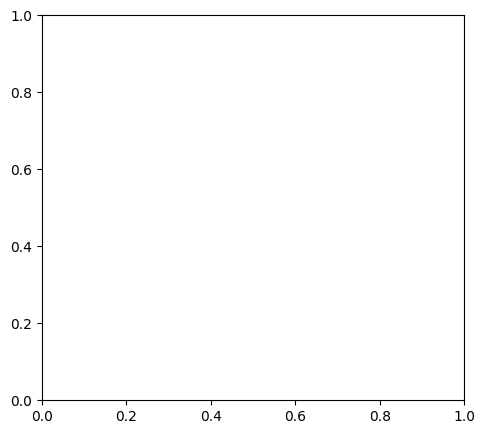

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()
print("CNN training history plots displayed.")

B. Build the CNN model
• Input Layer: A keras.Input layer explicitly defining the shape=(32, 32, 3).
• Data Preprocessing Layers:
• A Rescaling layer to normalize pixel values from the [0, 255] range to the [0, 1]
range.
• Add a simple data augmentation layer here, such as RandomFlip("horizontal").
• First Convolutional Block: This block will learn low-level features like edges and
textures.
• A Conv2D layer with 32 filters, a (3,3) kernel, padding='same', and relu activation.
The padding='same' argument ensures that the output feature map has the same
height and width as the input.
• A Conv2D layer with 32 filters, a (3,3) kernel, and relu activation.
• A MaxPooling2D layer with a (2, 2) pool size to downsample the feature map.
• A Dropout layer with a rate of 0.25 to provide regularization early on.
• Second Convolutional Block: This block will learn more complex features by
combining the features from the previous block.
• A Conv2D layer with 64 filters, a (3,3) kernel, padding='same', and relu activation.
• A Conv2D layer with 64 filters, a (3,3) kernel, and relu activation.
• A MaxPooling2D layer with a (2, 2) pool size.
• A Dropout layer with a rate of 0.25.
• Classifier Head: This is the fully-connected part of the network that performs the
final classification.
• A Flatten layer to convert the 3D feature maps from the convolutional blocks into a
1D vector.
• A Dense layer with 512 neurons and relu activation. This large layer has a high
capacity to learn complex combinations of features.
• A Dropout layer with a rate of 0.5. This high dropout rate is crucial for regularizing
the large dense layer and preventing overfitting.
• An Output Layer: A Dense layer with 10 neurons (one for each class) and a softmax
activation function.
• Model Summary: After defining the model, print its summary using
model.summary() to see the architecture, the number of parameters in each layer,
and the output shapes

# Task
Build a Keras Sequential CNN model for image classification starting with an explicit `keras.Input` layer of shape (32, 32, 3), followed by `Rescaling` (to normalize pixels from [0, 255] to [0, 1]) and `RandomFlip("horizontal")` layers for data preprocessing and augmentation. Integrate two convolutional blocks: the first block contains two `Conv2D` layers (32 filters, (3,3) kernel, `padding='same'`, `relu` activation for the first, then 32 filters, (3,3) kernel, `relu` activation for the second), followed by `MaxPooling2D` ((2,2) pool size) and `Dropout` (0.25 rate). The second block contains two `Conv2D` layers (64 filters, (3,3) kernel, `padding='same'`, `relu` activation for the first, then 64 filters, (3,3) kernel, `relu` activation for the second), followed by `MaxPooling2D` ((2,2) pool size) and `Dropout` (0.25 rate). Conclude with a classifier head comprising a `Flatten` layer, a `Dense` layer with 512 neurons and `relu` activation, a `Dropout` layer with a rate of 0.5, and a final 10-neuron `Dense` output layer with `softmax` activation. Finally, display the `model.summary()` to visualize the architecture.

## Define CNN Architecture with Preprocessing and Augmentation

### Subtask:
Build a Keras Sequential model starting with an explicit `keras.Input` layer, followed by `Rescaling` and `RandomFlip` for data preprocessing and augmentation. Integrate two convolutional blocks, each consisting of `Conv2D`, `MaxPooling2D`, and `Dropout` layers, as specified. Conclude with a classifier head comprising `Flatten`, a `Dense` layer with 512 neurons and `relu` activation, a `Dropout` layer with a rate of 0.5, and a final 10-neuron `Dense` output layer with `softmax` activation.


**Reasoning**:
To define the CNN model as specified, I will import the required Keras layers and construct a Sequential model with the specified input layer, preprocessing layers, two convolutional blocks, and a classifier head, then print its summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Rescaling, RandomFlip, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Initialize a Sequential model
cnn_model_augmented = Sequential()

# Add the Input layer explicitly
cnn_model_augmented.add(Input(shape=(32, 32, 3)))

# Data Preprocessing Layers
cnn_model_augmented.add(Rescaling(1./255))
cnn_model_augmented.add(RandomFlip("horizontal"))

# First Convolutional Block
cnn_model_augmented.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
cnn_model_augmented.add(Conv2D(32, (3, 3), activation='relu'))
cnn_model_augmented.add(MaxPooling2D((2, 2)))
cnn_model_augmented.add(Dropout(0.25))

# Second Convolutional Block
cnn_model_augmented.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
cnn_model_augmented.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model_augmented.add(MaxPooling2D((2, 2)))
cnn_model_augmented.add(Dropout(0.25))

# Classifier Head
cnn_model_augmented.add(Flatten())
cnn_model_augmented.add(Dense(512, activation='relu'))
cnn_model_augmented.add(Dropout(0.5))

# Output Layer
cnn_model_augmented.add(Dense(10, activation='softmax'))

# Print the model summary
cnn_model_augmented.summary()

print("CNN model with preprocessing and augmentation defined.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

CNN model with preprocessing and augmentation defined.


C.Compile and Train the Model
• Compile the Model: Compile your model with an appropriate optimizer, loss
function, and metric.
• Optimizer: Use the Adam optimizer.
• Loss Function: Use SparseCategoricalCrossentropy. We use the "sparse" version
because our y_train labels are single integers (e.g., [0], [1], [9]) and not one-hot
encoded vectors.
• Metrics: Track ['accuracy'].
• Train the Model: Use the model.fit() method to train your network.
• Pass the training data (x_train, y_train).
• Pass the validation data (x_val, y_val) to the validation_data argument to monitor
performance.
• Train for 20 epochs with a batch size of 64.